### Лавренов Константин ЭФБО-02-24

In [1]:
%%capture
%pip install -q --disable-pip-version-check numpy scipy sympy matplotlib

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.special import loggamma
from pathlib import Path

Path('рисунки_2').mkdir(exist_ok=True)
np.set_printoptions(precision=6, suppress=True)

def plane(ax):
    ax.axhline(0, color='gray', lw=0.7)
    ax.axvline(0, color='gray', lw=0.7)
    ax.set_xlabel('Re z')
    ax.set_ylabel('Im z')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

2.1

а) Умножаю числитель и знаменатель на 3 - i. Получается 10 - 11i.
Модуль: sqrt(221), угол: -arctan(11/10).

б) 1 + i = sqrt(2) \* exp(i\*pi/4), 1 - i = sqrt(2) \* exp(-i\*pi/4).
После возведения в степени получается 2 \* exp(2\*pi\*i) = 2.

в) В каждом слагаемом числитель равен 2^15, знаменатель равен -2^10.
Ответ: -32 - 32 = -64.

Для каждого числа тригонометрическая форма: r \* (cos(phi) + i\*sin(phi)).
Показательная форма: r \* exp(i\*phi).

In [3]:
i = sp.I
values = [(5+i)*(7-6*i)/(3+i), (1+i)**5/(1-i)**3,
          (-1+i*sp.sqrt(3))**15/(1-i)**20 + (-1-i*sp.sqrt(3))**15/(1+i)**20]
for label, value in zip('абв', values):
    z = sp.simplify(sp.expand_complex(value))
    print(label, 'z =', z, '; r =', sp.Abs(z), '; phi =', sp.arg(z))

а z = 10 - 11*I ; r = sqrt(221) ; phi = -atan(11/10)
б z = 2 ; r = 2 ; phi = 0
в z = -64 ; r = 64 ; phi = pi


2.2

1 + i = sqrt(2) \* exp(i\*pi/4).

Все решения: z[k] = 2^(1/16) \* exp(i\*(pi/32 + k\*pi/4)), k = 0, ..., 7.

[ 1.039245+0.102357j  0.66248 +0.807235j -0.102357+1.039245j
 -0.807235+0.66248j  -1.039245-0.102357j -0.66248 -0.807235j
  0.102357-1.039245j  0.807235-0.66248j ]
Ошибка проверки: 6.915539919559704e-15


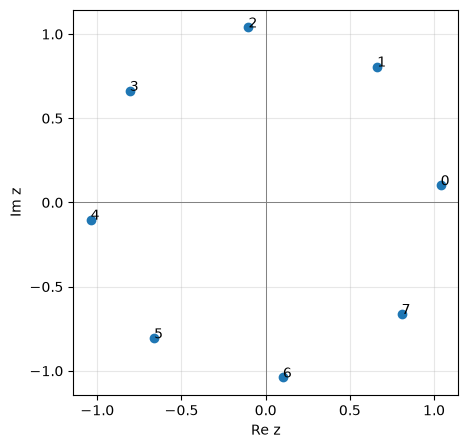

In [4]:
def roots(z, n):
    angles = (np.angle(z) + 2*np.pi*np.arange(n))/n
    return abs(z)**(1/n)*np.exp(1j*angles)

z = roots(1+1j, 8)
print(z)
print('Ошибка проверки:', np.max(abs(z**8-(1+1j))))
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(z.real, z.imag)
for k, v in enumerate(z):
    ax.annotate(str(k), (v.real, v.imag))
plane(ax)
plt.savefig('рисунки_2/2_2.png', dpi=140, bbox_inches='tight')
plt.show()

2.3

Для корня степени n: z[k] = |w|^(1/n) \* exp(i\*(arg(w) + 2\*pi\*k)/n).

а) w = 1, n = 8.

б) w = -9/2 + 9\*sqrt(3)\*i/2 = 9\*exp(2\*pi\*i/3), n = 4.

в) Под корнем: (-2 - 3i) - 5i + 11 = 9 - 8i, n = 3.

г) w = 1 - i, n = 9.

а [ 1.      +0.j        0.707107+0.707107j  0.      +1.j
 -0.707107+0.707107j -1.      +0.j       -0.707107-0.707107j
 -0.      -1.j        0.707107-0.707107j]
б [ 1.5     +0.866025j -0.866025+1.5j      -1.5     -0.866025j
  0.866025-1.5j     ]
в [ 2.225163-0.549759j -0.636476+2.201928j -1.588687-1.652168j]
г [ 1.035305-0.090577j  0.851311+0.596095j  0.26898 +1.003847j
 -0.43921 +0.941889j -0.941889+0.43921j  -1.003847-0.26898j
 -0.596095-0.851311j  0.090577-1.035305j  0.734867-0.734867j]


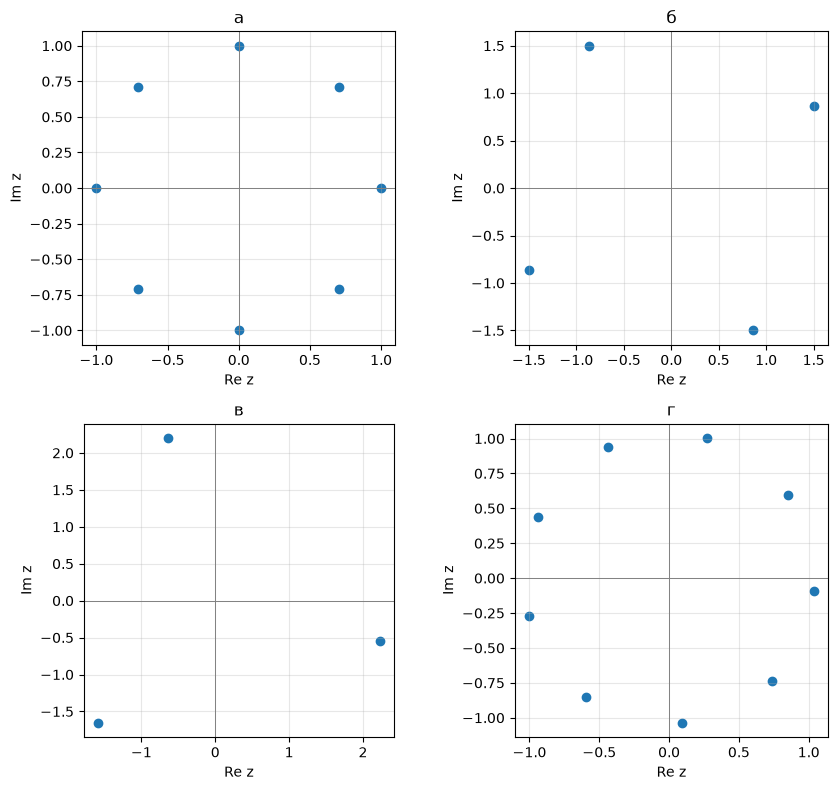

In [5]:
items = [('а', 1+0j, 8), ('б', -18/(1+1j*np.sqrt(3)), 4),
         ('в', (1-5j)/(1+1j)-5*(1+2j)/(2-1j)+11, 3), ('г', 1-1j, 9)]
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (label, w, n) in zip(axes.flat, items):
    z = roots(w, n)
    print(label, z)
    assert np.allclose(z**n, w)
    ax.scatter(z.real, z.imag)
    ax.set_title(label)
    plane(ax)
plt.tight_layout()
plt.savefig('рисунки_2/2_3.png', dpi=140)
plt.show()

2.4

Пусть z = x + i\*y.

а) Внутренность эллипса: x^2/3 + y^2/4 < 1. Фокусы: (0, -1) и (0, 1).

б) x + y < sqrt(2). Граница в множество не входит.

в) Из равенства расстояний до i и -i получаю y = 0. Затем (x + 1)^2 = x^2 + 1, то есть x = 0. Ответ: z = 0.

г) Для (i - z)/(z + i) действительная часть равна (1 - x^2 - y^2)/(x^2 + (y+1)^2), мнимая — 2\*x/(x^2 + (y+1)^2).
Обе части положительны: x > 0 и x^2 + y^2 < 1.

д) -2\*pi/3 > -5\*pi/6. Указанным двум неравенствам одновременно не удовлетворяет ни один угол. Множество пустое.

е) Обозначу U = 3\*x - x^2 - y^2 - y, V = x - 3\*y - 3.
Нужная область: V <= -sqrt(3)\*abs(U). Точки z = -i и z = 3 исключены: дробь или её аргумент не определены.

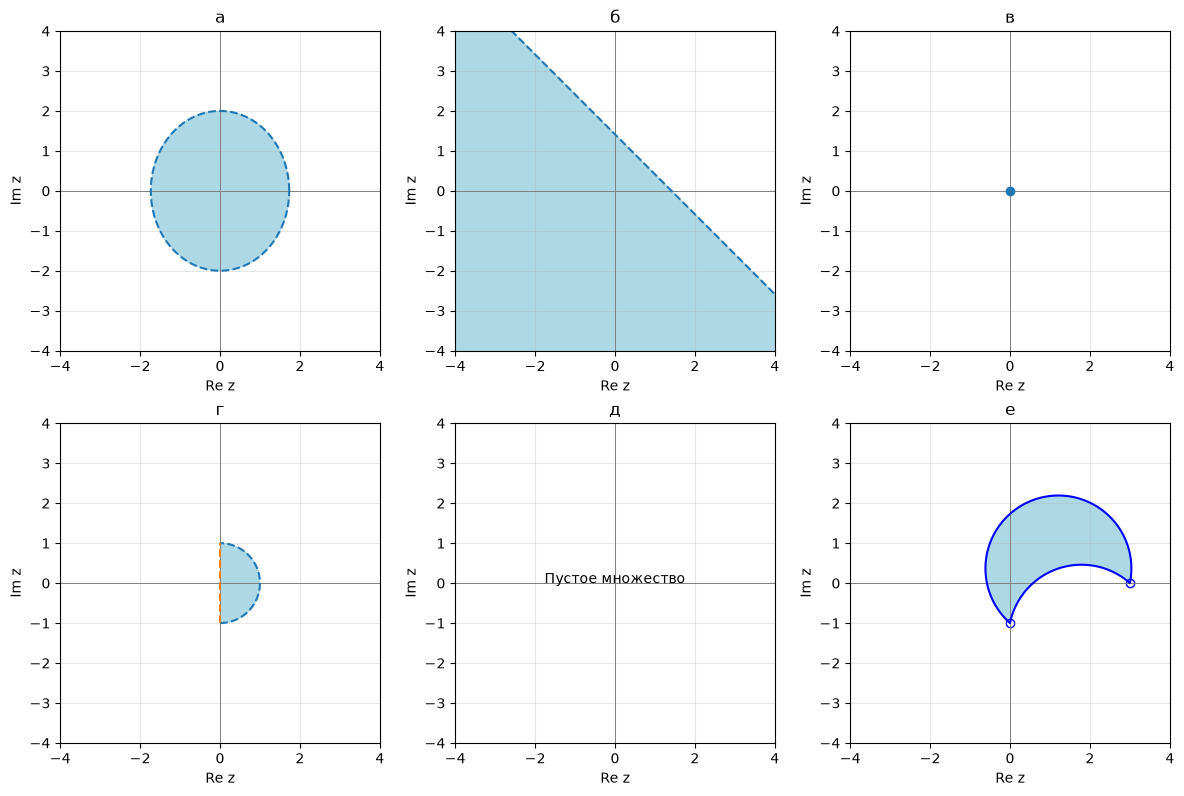

In [6]:
x = np.linspace(-4, 4, 601)
y = np.linspace(-4, 4, 601)
X, Y = np.meshgrid(x, y)
U = 3*X-X**2-Y**2-Y
V = X-3*Y-3
masks = [X**2/3+Y**2/4 < 1, X+Y < np.sqrt(2), None,
         (X > 0) & (X**2+Y**2 < 1), np.zeros(X.shape, bool),
         (V <= -np.sqrt(3)*abs(U)) & (X**2+(Y+1)**2 > 1e-10)
         & ((X-3)**2+Y**2 > 1e-10)]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for k, ax in enumerate(axes.flat):
    if masks[k] is not None:
        ax.contourf(X, Y, masks[k].astype(int), levels=[0.5, 1.5], colors=['lightblue'])
    ax.set_title('абвгде'[k])
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    plane(ax)
t = np.linspace(0, 2*np.pi, 300)
axes[0, 0].plot(np.sqrt(3)*np.cos(t), 2*np.sin(t), '--')
axes[0, 1].plot(x, np.sqrt(2)-x, '--')
axes[0, 2].plot(0, 0, 'o')
t = np.linspace(-np.pi/2, np.pi/2, 200)
axes[1, 0].plot(np.cos(t), np.sin(t), '--')
axes[1, 0].plot([0, 0], [-1, 1], '--')
axes[1, 1].text(0, 0, 'Пустое множество', ha='center')
axes[1, 2].contour(X, Y, V+np.sqrt(3)*abs(U), levels=[0], colors='blue')
axes[1, 2].scatter([0, 3], [-1, 0], facecolors='white', edgecolors='blue')
plt.tight_layout()
plt.savefig('рисунки_2/2_4.png', dpi=140)
plt.show()

2.5

В уравнении стоят слагаемые conj(B)\*z + B\*conj(z).

Делю на A и выделяю квадрат:

|z + B/A|^2 = (|B|^2 - A\*C)/A^2.

Центр: -B/A. Радиус: sqrt(|B|^2 - A\*C)/A.
Радиус положителен, так как A > 0 и A\*C < |B|^2.

2.6

In [7]:
x = sp.symbols('x')
p = x**11+x**10+x**8-2*x**7-x**5+x**4+2*x**2+2*x+2
z = np.array([complex(v) for v in sp.nroots(p, n=30, maxsteps=200)])
for k, v in enumerate(z, 1):
    print(k, f'{v.real:.9f} {v.imag:+.9f}i')
print('Сумма модулей:', sum(abs(z)))
print('Наибольшая действительная часть:', max(z.real))
print('Ошибка подстановки:', max(abs(np.polyval([1,1,0,1,-2,0,-1,1,0,2,2,2], z))))

1 -1.776769025 +0.000000000i
2 -0.707434455 -0.464374726i
3 -0.707434455 +0.464374726i
4 -0.450037113 -0.803923144i
5 -0.450037113 +0.803923144i
6 -0.012500181 -1.182699082i
7 -0.012500181 +1.182699082i
8 0.477754524 -0.901075231i
9 0.477754524 +0.901075231i
10 1.080601737 -0.323893119i
11 1.080601737 +0.323893119i
Сумма модулей: 11.97338446971212
Наибольшая действительная часть: 1.0806017373578454
Ошибка подстановки: 2.4424906541753444e-14


2.7

Считаю через гамма-функцию. В пункте в беру w = 1/z.

а) (4.367449140640134+4.851629765157813j)
б) 0.8378693695500427 рад; 48.00637865850454 градусов


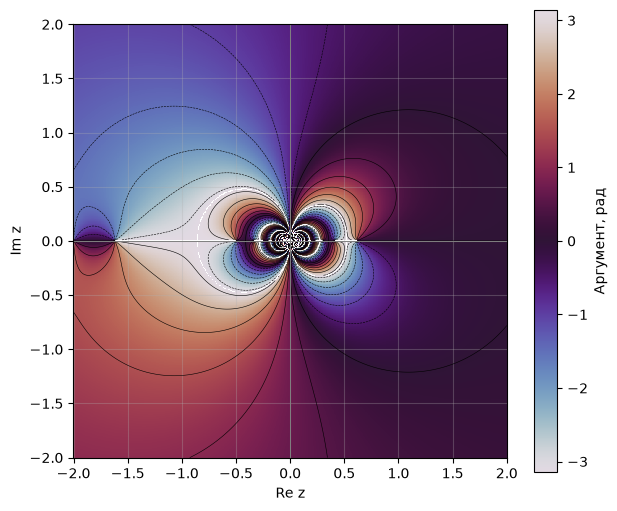

In [8]:
z, w = 1+1j, 1-1j
log_c = loggamma(z+1)-loggamma(w+1)-loggamma(z-w+1)
c = np.exp(log_c)
print('а)', c)
print('б)', np.angle(c), 'рад;', np.degrees(np.angle(c)), 'градусов')
x = np.linspace(-2, 2, 600)
y = np.linspace(-2, 2, 600)
X, Y = np.meshgrid(x, y)
Z = X+1j*Y
with np.errstate(all='ignore'):
    L = loggamma(Z+1)-loggamma(1/Z+1)-loggamma(Z-1/Z+1)
    arg = (L.imag+np.pi) % (2*np.pi)-np.pi
arg[abs(Z) < 0.025] = np.nan
# Не соединяю линией скачок аргумента от pi к -pi.
jump = np.zeros(arg.shape, bool)
jump[:, 1:] |= abs(np.diff(arg, axis=1)) > np.pi
jump[1:, :] |= abs(np.diff(arg, axis=0)) > np.pi
A = np.ma.masked_where(jump | ~np.isfinite(arg), arg)
fig, ax = plt.subplots(figsize=(7, 6))
img = ax.pcolormesh(X, Y, A, cmap='twilight', vmin=-np.pi, vmax=np.pi, shading='auto')
ax.contour(X, Y, A, levels=np.linspace(-3, 3, 13), colors='black', linewidths=0.4)
fig.colorbar(img, ax=ax, label='Аргумент, рад')
plane(ax)
plt.savefig('рисунки_2/2_7.png', dpi=140, bbox_inches='tight')
plt.show()

2.8

Нужный корень: lambda = exp(i\*pi/7).

det(A + lambda\*I) = (7 + lambda)\*(2 + lambda) - 30 = lambda^2 + 9\*lambda - 16.

In [9]:
lam = np.exp(1j*np.pi/7)
d = lam**2+9*lam-16
print('Действительная часть:', d.real)
print('Мнимая часть:', d.imag)

Действительная часть: -7.2677903870194935
Мнимая часть: 4.686785134526053


2.9

Для z^2 + c проверяю, какие точки не уходят за окружность радиуса 2.
Закрашенная внутренняя область — заполненное множество Жюлиа; его граница — множество Жюлиа.

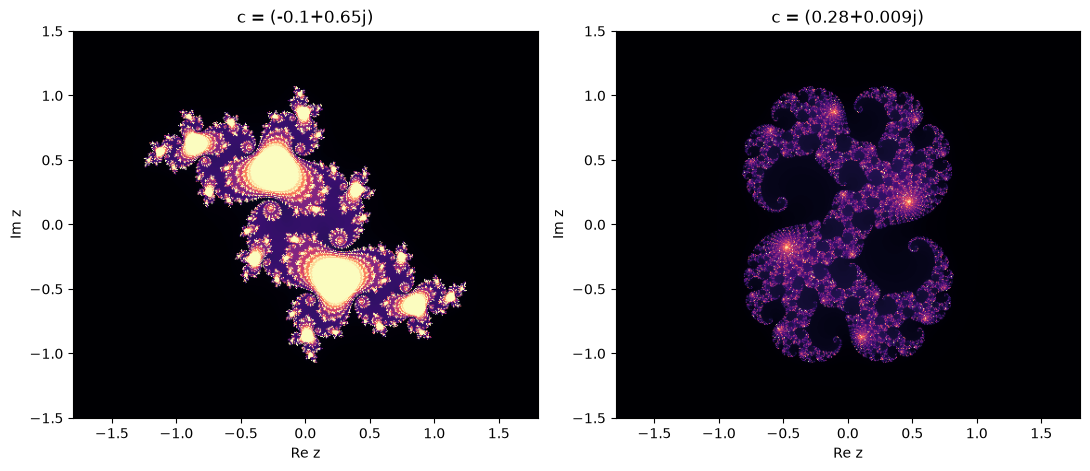

In [10]:
x = np.linspace(-1.8, 1.8, 500)
y = np.linspace(-1.5, 1.5, 420)
X, Y = np.meshgrid(x, y)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, c in zip(axes, [-0.1+0.65j, 0.28+0.009j]):
    Z = X+1j*Y
    active = np.ones(Z.shape, bool)
    counts = np.zeros(Z.shape, int)
    for k in range(400):
        Z[active] = Z[active]**2+c
        active &= abs(Z) <= 2
        counts[active] += 1
    ax.imshow(counts, origin='lower', extent=[x[0],x[-1],y[0],y[-1]], cmap='magma')
    ax.set_title(f'c = {c}')
    ax.set_xlabel('Re z')
    ax.set_ylabel('Im z')
plt.tight_layout()
plt.savefig('рисунки_2/2_9_квадратичные.png', dpi=140)
plt.show()

г) Для дробных функций использую обратные итерации. На каждом шаге выбираю один из корней случайно.

Для первой функции: z^5 = (i\*w - 1)/(w - i).

Для второй: z^2 = (w - i)/(w + 1).

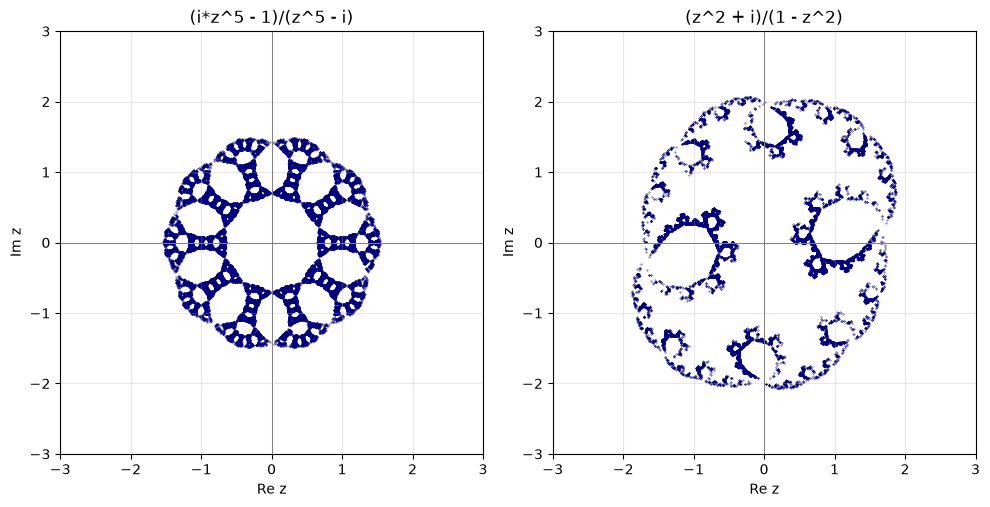

In [11]:
rng = np.random.default_rng(24)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, degree in zip(axes, [5, 2]):
    w = 0.3+0.4j
    points = []
    for k in range(101000):
        v = (1j*w-1)/(w-1j) if degree == 5 else (w-1j)/(w+1)
        angle = (np.angle(v)+2*np.pi*rng.integers(degree))/degree
        w = abs(v)**(1/degree)*np.exp(1j*angle)
        if k >= 1000:
            points.append(w)
    points = np.array(points)
    ax.scatter(points.real, points.imag, s=0.08, color='navy', rasterized=True)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title('(i*z^5 - 1)/(z^5 - i)' if degree == 5 else '(z^2 + i)/(1 - z^2)')
    plane(ax)
plt.tight_layout()
plt.savefig('рисунки_2/2_9_дробные.png', dpi=160)
plt.show()

2.10

Для z = x + i\*y точка на единичной сфере:

X = 2\*x/(1 + x^2 + y^2), Y = 2\*y/(1 + x^2 + y^2), Z = (x^2 + y^2 - 1)/(1 + x^2 + y^2).

Прямая: y = x. Окружность: x^2 + y^2 = 1. Парабола: y = x^2. Гипербола: x\*y = 1.

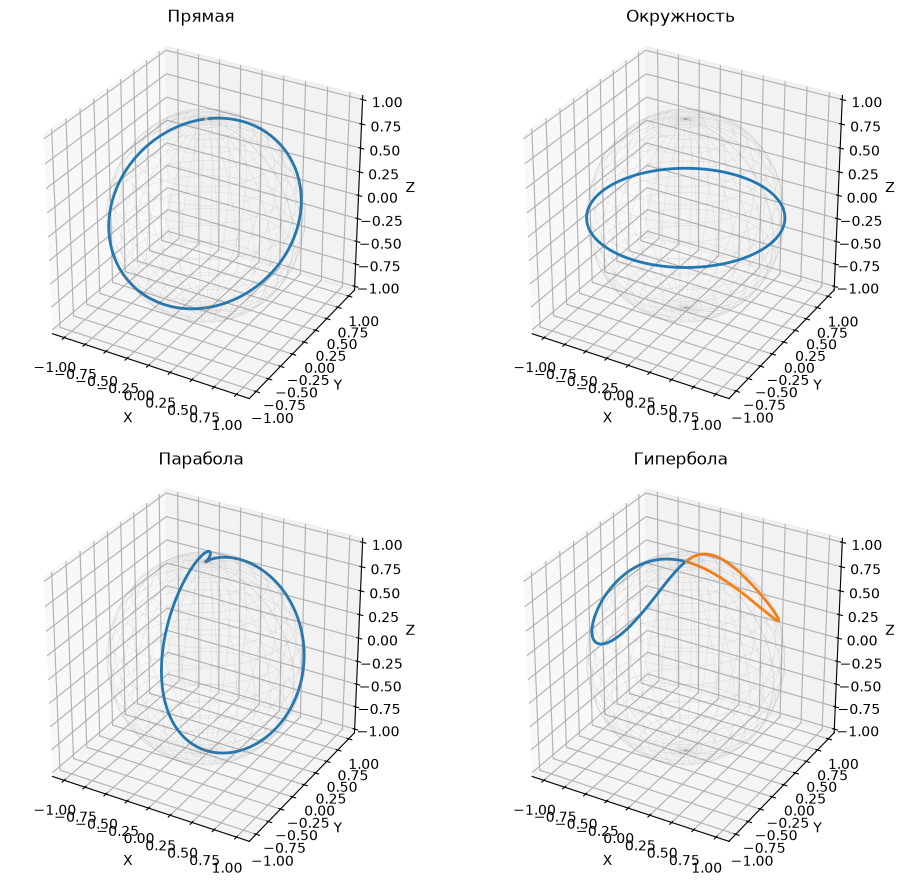

In [12]:
def sphere_curve(ax, x, y):
    d = 1+x*x+y*y
    ax.plot(2*x/d, 2*y/d, (d-2)/d, lw=2)

def sphere(ax):
    u, v = np.meshgrid(np.linspace(0, 2*np.pi, 35), np.linspace(0, np.pi, 20))
    ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                      color='gray', alpha=0.18, linewidth=0.4)
    ax.set_box_aspect((1, 1, 1))
    ax.set(xlabel='X', ylabel='Y', zlabel='Z')

t = np.linspace(-50, 50, 12000)
a = np.linspace(0, 2*np.pi, 600)
fig = plt.figure(figsize=(10, 9))
curves = [(t,t), (np.cos(a),np.sin(a)), (t,t*t)]
for k, title in enumerate(['Прямая', 'Окружность', 'Парабола', 'Гипербола']):
    ax = fig.add_subplot(2, 2, k+1, projection='3d')
    sphere(ax)
    if k < 3:
        sphere_curve(ax, *curves[k])
    else:
        for sign in [-1, 1]:
            t1 = sign*np.geomspace(0.015, 70, 2000)
            sphere_curve(ax, t1, 1/t1)
    ax.set_title(title)
plt.tight_layout()
plt.savefig('рисунки_2/2_10_кривые.png', dpi=140)
plt.show()

2.10 — спираль

Беру a = 1, b = 0.18. Тогда x = exp(0.18\*phi)\*cos(phi), y = exp(0.18\*phi)\*sin(phi).

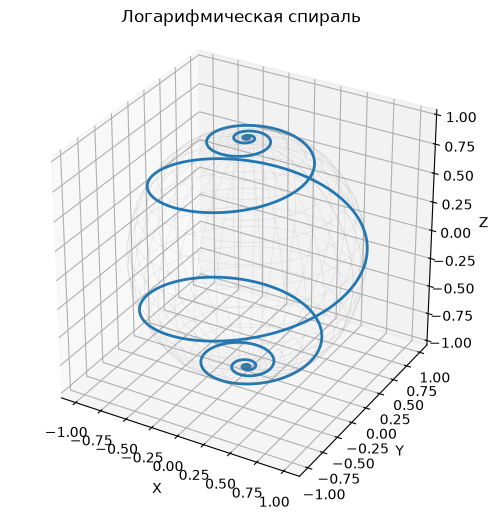

In [13]:
phi = np.linspace(-12*np.pi, 12*np.pi, 7000)
r = np.exp(0.18*phi)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection='3d')
sphere(ax)
sphere_curve(ax, r*np.cos(phi), r*np.sin(phi))
ax.set_title('Логарифмическая спираль')
plt.savefig('рисунки_2/2_10_спираль.png', dpi=140, bbox_inches='tight')
plt.show()

Материалы: [множества Жюлиа](https://ru.wikipedia.org/wiki/Множество_Жюлиа), [метод обратных итераций](https://arxiv.org/abs/1312.1457).